This notebook brings the different components of the applications together


*   Digit recognition (predictive AI)
*   Results' ouput as text (generative AI)
*   Results' output as coordinate + temperature (generative AI - agent+tools)
*   Results' output as map (geographic information systems)

# Part 1: Application

In [ ]:
!pip install -qU langchain langgraph langsmith langchain-openai langchain_community pyowm langchain-tavily

In [2]:
import os
import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [3]:
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""

In [4]:
if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your TavilySearch API key: ")

Enter your TavilySearch API key: ··········


In [5]:
os.environ["OPENWEATHERMAP_API_KEY"] = ""

In [6]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_community.utilities import OpenWeatherMapAPIWrapper
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode


@tool
def get_weather(location: str):
    """Call to get the current weather."""
    weather = OpenWeatherMapAPIWrapper()
    weather_data = weather.run(location)
    return weather_data

search_engine = TavilySearch(max_results=2)

tools = [search_engine, get_weather]

llm = ChatOpenAI(model="gpt-5.4-nano") # gpt-4o-mini gpt-5.4-nano
llm_with_tools = llm.bind_tools(tools)

def call_model(state: MessagesState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, ["tools", END])
workflow.add_edge("tools", "agent")

app = workflow.compile()

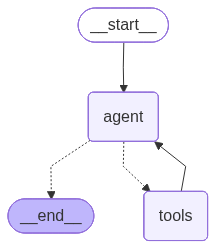

In [7]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

## Example of map using geojson, folium and gradio

In [8]:
!pip install -q gradio

In [ ]:
# This code was generated from ChatGPT and then modified to have a satisfactory execution
import folium
import gradio as gr
import json

# Sample GeoJSON data (you can replace this with your own)
geojson_sample = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "Sample Polygon"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [-100.0, 40.0],
                        [-105.0, 45.0],
                        [-110.0, 40.0],
                        [-100.0, 40.0]
                    ]
                ]
            }
        }
    ]
}

def generate_map(geojson_data_str):
    # Parse GeoJSON string
    try:
        geojson_data = json.loads(geojson_data_str)
    except json.JSONDecodeError:
        return "Invalid GeoJSON input."

    # Create a Folium map
    m = folium.Map(location=[40, -100],
                   zoom_start=4,
                   tiles = "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
                   attr= '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors') # for the tile, see https://leaflet-extras.github.io/leaflet-providers/preview/)

    # Add GeoJSON layer
    folium.GeoJson(geojson_data, name="geojson").add_to(m)


    return m._repr_html_()

# Gradio interface
interface = gr.Interface(
    fn=generate_map,
    inputs=gr.Textbox(label="Enter GeoJSON Data", lines=10, placeholder="Paste your GeoJSON here..."),
    outputs=gr.HTML(label="Map Output")
)

if __name__ == "__main__":
    interface.launch(debug=True)

## Image input + Digit recognition + Verbalization as text + Display on a map

In [10]:
!pip install -q gradio

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import numpy as np
from scipy.spatial.distance import cdist

class GraphNet(nn.Module):
    def __init__(self, img_size=28, pred_edge=False):
        super(GraphNet, self).__init__()
        self.pred_edge = pred_edge
        N = img_size * img_size
        self.fc = nn.Linear(N, 10, bias=False)
        if pred_edge:
            col, row = np.meshgrid(np.arange(img_size), np.arange(img_size))
            coord = np.stack((col, row), axis=2).reshape(-1, 2)
            coord = (coord - np.mean(coord, axis=0)) / (np.std(coord, axis=0) + 1e-5)
            coord = torch.from_numpy(coord).float()  # 784,2
            coord = torch.cat((coord.unsqueeze(0).repeat(N, 1,  1),
                                    coord.unsqueeze(1).repeat(1, N, 1)), dim=2)
            #coord = torch.abs(coord[:, :, [0, 1]] - coord[:, :, [2, 3]])
            self.pred_edge_fc = nn.Sequential(nn.Linear(4, 64),
                                              nn.ReLU(),
                                              nn.Linear(64, 1),
                                              nn.Tanh())
            self.register_buffer('coord', coord)
        else:
            # precompute adjacency matrix before training
            A = self.precompute_adjacency_images(img_size)
            self.register_buffer('A', A)


    @staticmethod
    def precompute_adjacency_images(img_size):
        col, row = np.meshgrid(np.arange(img_size), np.arange(img_size))
        coord = np.stack((col, row), axis=2).reshape(-1, 2) / img_size
        dist = cdist(coord, coord)
        sigma = 0.05 * np.pi

        A = np.exp(- dist / sigma ** 2)

        A[A < 0.01] = 0
        A = torch.from_numpy(A).float()

        # Normalization as per (Kipf & Welling, ICLR 2017)
        D = A.sum(1)  # nodes degree (N,)
        D_hat = (D + 1e-5) ** (-0.5)
        A_hat = D_hat.view(-1, 1) * A * D_hat.view(1, -1)  # N,N

        # Some additional trick I found to be useful
        A_hat[A_hat > 0.0001] = A_hat[A_hat > 0.0001] - 0.2

        #print(A_hat[:10, :10])
        return A_hat

    def forward(self, x):
        B = x.size(0)
        if self.pred_edge:
            self.A = self.pred_edge_fc(self.coord).squeeze()

        avg_neighbor_features = (torch.bmm(self.A.unsqueeze(0).expand(B, -1, -1),
                                 x.view(B, -1, 1)).view(B, -1))
        return self.fc(avg_neighbor_features)

In [12]:
import folium


# input: json => output: nice text
def verbalize (outcome):
  prompt = """

  You are an assistant specialized into turning information from a json input into some nice text.

  The first value stands for a predicted class and the second value stands for the probability.

  Turn the following input into a nice text:

  """
  user_input = prompt + str(outcome)

  result = app.invoke({"messages": [("human", user_input)]})

  return result["messages"][-1].content

# input: number of cities, output: valid geojson
def show_on_map (outcome):

  prompt = """

  You are an assistant specialized into returning information about the closest cities to the city of Dresden, Germany.

  The output should be formatted as geojson. Return their coordinates, the distance in km and the temperature values of these cities.

  Do not add any additional text to the output. The ouput should start and finish with {} as expected of a properly-formatted geojson.

  For example, {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "Sample Polygon"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [-100.0, 40.0],
                        [-105.0, 45.0],
                        [-110.0, 40.0],
                        [-100.0, 40.0]
                    ]
                ]
            }
        }
    ]
  }

  Do not add ```json.

  Key for cities: 'city'

  Key for distance: 'distance_km'

  Key for temperature: 'temperature_c'

  Number of cities:

  """
  print("*** Current number of cities: ", list(outcome.keys())[0])
  user_input = prompt + str(list(outcome.keys())[0]) # https://stackoverflow.com/a/77694283

  result = app.invoke({"messages": [("human", user_input)]})
  print("***LLM-generated coordinates: ", result["messages"][-1].content)

  data = json.loads(result["messages"][-1].content)
  print("***Data for map: ", data)
  # for alternatives to folium, see https://leafmap.org/get-started/
  m = folium.Map(location=(51.05, 13.73),
                 tiles = "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
                 attr= '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors')

  folium.GeoJson(data,
                tooltip=folium.GeoJsonTooltip(fields=["city", "distance_km", "temperature_c"]),
                popup=folium.GeoJsonPopup(fields=["city", "distance_km", "temperature_c"])
                ).add_to(m)

  folium.Marker(
      location=[51.049259, 13.73836],
      tooltip="Dresden",
      popup="Dresden",
      icon=folium.Icon(color="green"),
  ).add_to(m)

  return m._repr_html_()

In [13]:
import cv2
from torchvision import transforms
from torchvision.transforms import v2
import numpy as np
import gradio as gr
from PIL import Image
import json


## Function definition
def transform_image(image):
  transf = v2.Compose([
              transforms.Grayscale(num_output_channels=1),
              transforms.Resize((28, 28)),
              transforms.ToTensor(),
              transforms.Normalize((0.1307,), (0.3081,))
               ])

  return transf(image)

def predict_digit(image, trained_model):

  outputs = trained_model(image)
  probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
  # https://www.youtube.com/watch?v=a8aS3ZYlzDM
  values, indices = torch.topk(probabilities, 5)

  labels = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

  return {labels[i]:v.item() for i, v in zip(indices, values)}

def recognize_digit(image):
  if image is None:
    return None, "No Prediction", "Please upload an image.", None # Default values for no image
  else:
    pil_img = Image.fromarray(image["composite"])
    inv = transforms.functional.invert(pil_img)
    outcome = predict_digit(transform_image(inv), trained_model)
    print("** Digit recognition outcome: ", outcome)
    print("** Type of the outcome: ", type(outcome))
    outcome_as_text = verbalize (outcome)
    outcome_on_map = show_on_map (outcome)
    return image["composite"], outcome, outcome_as_text, outcome_on_map


## Function use

trained_model = GraphNet()
checkpoint_path = '/content/my_mnist_model_graph.pt'

# load the weights of the trained model
checkpoint = torch.load(checkpoint_path, weights_only=True)
trained_model.load_state_dict(checkpoint)


with gr.Blocks() as demo:
    with gr.Row(equal_height=True):
        im_input = gr.ImageEditor(type="numpy", image_mode="L", crop_size="1:1", label="Input Image Component") # Sketchpad, ImageEditor
        im_preview = gr.Image(label="Output Image Component")
        predicted_label = gr.Label(label="Class predictions")
    with gr.Row():
        text_box = gr.TextArea(label ="Predictions as text")
    with gr.Row():
        map_component = gr.HTML(label="Map Output")

    im_input.upload(recognize_digit, outputs=[im_preview, predicted_label, text_box, map_component], inputs=im_input, show_progress="full")
    #im_input.change(recognize_digit, outputs=[im_preview, predicted_label, text_box, map_component], inputs=im_input, show_progress="full")

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://327fa134ed2af32ff3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


** Digit recognition outcome:  {'4': 0.6925452947616577, '9': 0.15146604180335999, '6': 0.08112844079732895, '5': 0.04160904511809349, '7': 0.010529734194278717}
** Type of the outcome:  <class 'dict'>
*** Current number of cities:  4
***LLM-generated coordinates:  {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {
        "city": "Dresden, Germany",
        "distance_km": 0,
        "temperature_c": 18.03
      },
      "geometry": {
        "type": "Point",
        "coordinates": [13.7373, 51.0504]
      }
    },
    {
      "type": "Feature",
      "properties": {
        "city": "Leipzig, Germany",
        "distance_km": 101.8,
        "temperature_c": 18.85
      },
      "geometry": {
        "type": "Point",
        "coordinates": [12.3731, 51.3397]
      }
    },
    {
      "type": "Feature",
      "properties": {
        "city": "Chemnitz, Germany",
        "distance_km": 84.7,
        "temperature_c": 16.39
      },
      "g

Example of correct geojson

```javascript
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {
        "city": "Chemnitz",
        "distance_km": 82,
        "temperature_c": 10.37
      },
      "geometry": {
        "type": "Point",
        "coordinates": [12.9222, 50.8278]
      }
    },
    {
      "type": "Feature",
      "properties": {
        "city": "Leipzig",
        "distance_km": 100,
        "temperature_c": 16.06
      },
      "geometry": {
        "type": "Point",
        "coordinates": [12.3731, 51.3397]
      }
    },
    {
      "type": "Feature",
      "properties": {
        "city": "Meissen",
        "distance_km": 25,
        "temperature_c": 12.75
      },
      "geometry": {
        "type": "Point",
        "coordinates": [13.4809, 51.1605]
      }
    },
    {
      "type": "Feature",
      "properties": {
        "city": "Cottbus",
        "distance_km": 113,
        "temperature_c": 17.01
      },
      "geometry": {
        "type": "Point",
        "coordinates": [14.3423, 51.7592]
      }
    }
  ]
}
```

# Part 2: Code Generation

This is a simple example to test map (code) generation using an open model from the SAIA service

In [18]:
my_saia_api_key = 'my_api_key' # Replace with your API key


## See all models available through the SAIA API

In [19]:
# code adapted from https://andrewm4894.com/2022/10/20/colab-to-just-run-some-curl/
# see also https://docs.hpc.gwdg.de/services/ai-services/saia/index.html#api-request for additional models
import json
import os

curl = """
 curl -X POST \
  --url https://chat-ai.academiccloud.de/v1/models \
  --header 'Accept: application/json' \
  --header 'Authorization: Bearer """+my_saia_api_key+"""' \
  --header 'Content-Type: application/json'
"""

response = json.loads(os.popen(curl).read())
response['data']

[{'input': ['text'],
  'output': ['text'],
  'demand': 0,
  'status': 'ready',
  'name': 'Qwen 3 Coder 30B A3B Instruct',
  'owned_by': 'chat-ai',
  'id': 'qwen3-coder-30b-a3b-instruct',
  'created': 1776421888,
  'object': 'model'},
 {'input': ['text', 'image'],
  'output': ['text', 'thought'],
  'demand': 5,
  'status': 'ready',
  'name': 'Qwen 3.5 122B A10B',
  'owned_by': 'chat-ai',
  'id': 'qwen3.5-122b-a10b',
  'created': 1776421888,
  'object': 'model'},
 {'input': ['text'],
  'output': ['text'],
  'demand': 1,
  'status': 'ready',
  'name': 'GLM-4.7',
  'owned_by': 'chat-ai',
  'id': 'glm-4.7',
  'created': 1776421888,
  'object': 'model'},
 {'input': ['text', 'image'],
  'output': ['text', 'thought'],
  'demand': 0,
  'status': 'ready',
  'name': 'Qwen 3.5 27B',
  'owned_by': 'chat-ai',
  'id': 'qwen3.5-27b',
  'created': 1776421888,
  'object': 'model'},
 {'input': ['text'],
  'output': ['text'],
  'demand': 0,
  'status': 'ready',
  'name': 'Apertus 70B Instruct 2509',
  'ow

## Generate some code

In [20]:
# if needed install the penAI SDK first: `pip install openai`

from openai import OpenAI

base_url = "https://chat-ai.academiccloud.de/v1"
current_model = "meta-llama-3.1-8b-instruct" # meta-llama-3.1-8b-instruct, deepseek-r1-distill-llama-70b # openai-gpt-oss-120b


client = OpenAI(api_key=my_saia_api_key, base_url=base_url)

instructions = """
You are a helpful assistant. Write a code in python to show a map using folium.
The map should be centered on Dresden, Germany.
I do not want to save the map as html.
"""

response = client.chat.completions.create(
    model=current_model,
    messages=[
        {"role": "system", "content": instructions},
        {"role": "user", "content": "Hello"},
    ],
    stream=False
)

print(response.choices[0].message.content)

Here's a simple example of how you can use the Folium library in Python to display a map centered on Dresden, Germany.

```python
# Import necessary libraries
import folium

# Define the latitude and longitude of Dresden, Germany
latitude = 51.0653
longitude = 13.7335

# Create a new map centered on Dresden, Germany
m = folium.Map(location=[latitude, longitude], zoom_start=13)

# Display the map
m
```

However, this code will only display the map in Jupyter Notebook or other similar environments. If you're running this code in a standard Python environment, it won't display the map.

To display the map in a standard Python environment, you can use the `IPython.display` module to display the map in the Jupyter Notebook-like environment.

```python
# Import necessary libraries
import folium
from IPython.display import display, Image

# Define the latitude and longitude of Dresden, Germany
latitude = 51.0653
longitude = 13.7335

# Create a new map centered on Dresden, Germany
m = folium.M

Execution here

In [22]:
# Import necessary libraries
import folium

# Define the latitude and longitude of Dresden, Germany
latitude = 51.0653
longitude = 13.7335

# Create a new map centered on Dresden, Germany
m = folium.Map(location=[latitude, longitude], zoom_start=13)

# Display the map
m